# FathomIDS Alert Analytics

A data analysis project examining security alert patterns from FathomIDS, a network monitoring system for maritime IT infrastructure. This notebook covers data generation, cleaning, exploratory analysis, visualization, and business recommendations.

**Note on data:** This dataset is synthetically generated to simulate realistic alert patterns, since real ship IT security logs are not publicly available. Distributions for severity, zone, and response time are modeled to reflect plausible operational scenarios on a passenger/cargo vessel.

## Step 1: Generate Alert Dataset
Creating a simulated dataset of 2,500 network security alerts across 5 ship zones, with realistic severity levels, alert types, and response times.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil, os, random
from datetime import datetime, timedelta

np.random.seed(42)
n = 2500
zones = ['Bridge', 'Engine Room', 'Crew Quarters', 'Cargo Hold', 'Passenger WiFi']
severities = ['Low', 'Medium', 'High', 'Critical']
alert_types = ['Unauthorized Access', 'Port Scan', 'Malware Signature', 'Failed Login', 'Bandwidth Anomaly', 'Firmware Mismatch']

start = datetime(2026, 1, 1)
data = {
    'alert_id': range(1, n+1),
    'timestamp': [start + timedelta(minutes=random.randint(0, 200000)) for _ in range(n)],
    'zone': np.random.choice(zones, n),
    'severity': np.random.choice(severities, n, p=[0.4, 0.3, 0.2, 0.1]),
    'alert_type': np.random.choice(alert_types, n),
    'response_time_min': np.round(np.random.exponential(15, n), 1),
    'false_positive': np.random.choice([True, False], n, p=[0.34, 0.66])
}
df = pd.DataFrame(data).sort_values('timestamp').reset_index(drop=True)
df.to_csv('fathomids_alerts.csv', index=False)
print(f"Generated {len(df)} alert records")
df.head(10)

Generated 2500 alert records


,alert_id,timestamp,zone,severity,alert_type,response_time_min,false_positive
0,1678,2026-01-01 00:35:00,Engine Room,Low,Bandwidth Anomaly,15.9,True
1,1732,2026-01-01 01:37:00,Engine Room,Low,Bandwidth Anomaly,20.7,False
2,2145,2026-01-01 02:28:00,Passenger WiFi,Critical,Firmware Mismatch,23.9,False
3,2387,2026-01-01 05:51:00,Cargo Hold,Medium,Malware Signature,11.3,False
4,1656,2026-01-01 08:40:00,Engine Room,Low,Bandwidth Anomaly,2.4,False
5,266,2026-01-01 10:14:00,Bridge,High,Bandwidth Anomaly,11.1,False
6,985,2026-01-01 10:39:00,Crew Quarters,Critical,Firmware Mismatch,1.3,False
7,938,2026-01-01 12:51:00,Bridge,High,Failed Login,31.1,True
8,998,2026-01-01 13:42:00,Bridge,High,Malware Signature,62.1,False
9,416,2026-01-01 13:44:00,Passenger WiFi,High,Port Scan,5.0,False


## Step 2: Exploratory Visualization
Before drawing conclusions, I wanted to see the shape of the data first — which zones generate the most alerts, how severity is distributed, and whether false positives cluster in any particular area. These four views set up the recommendations below.

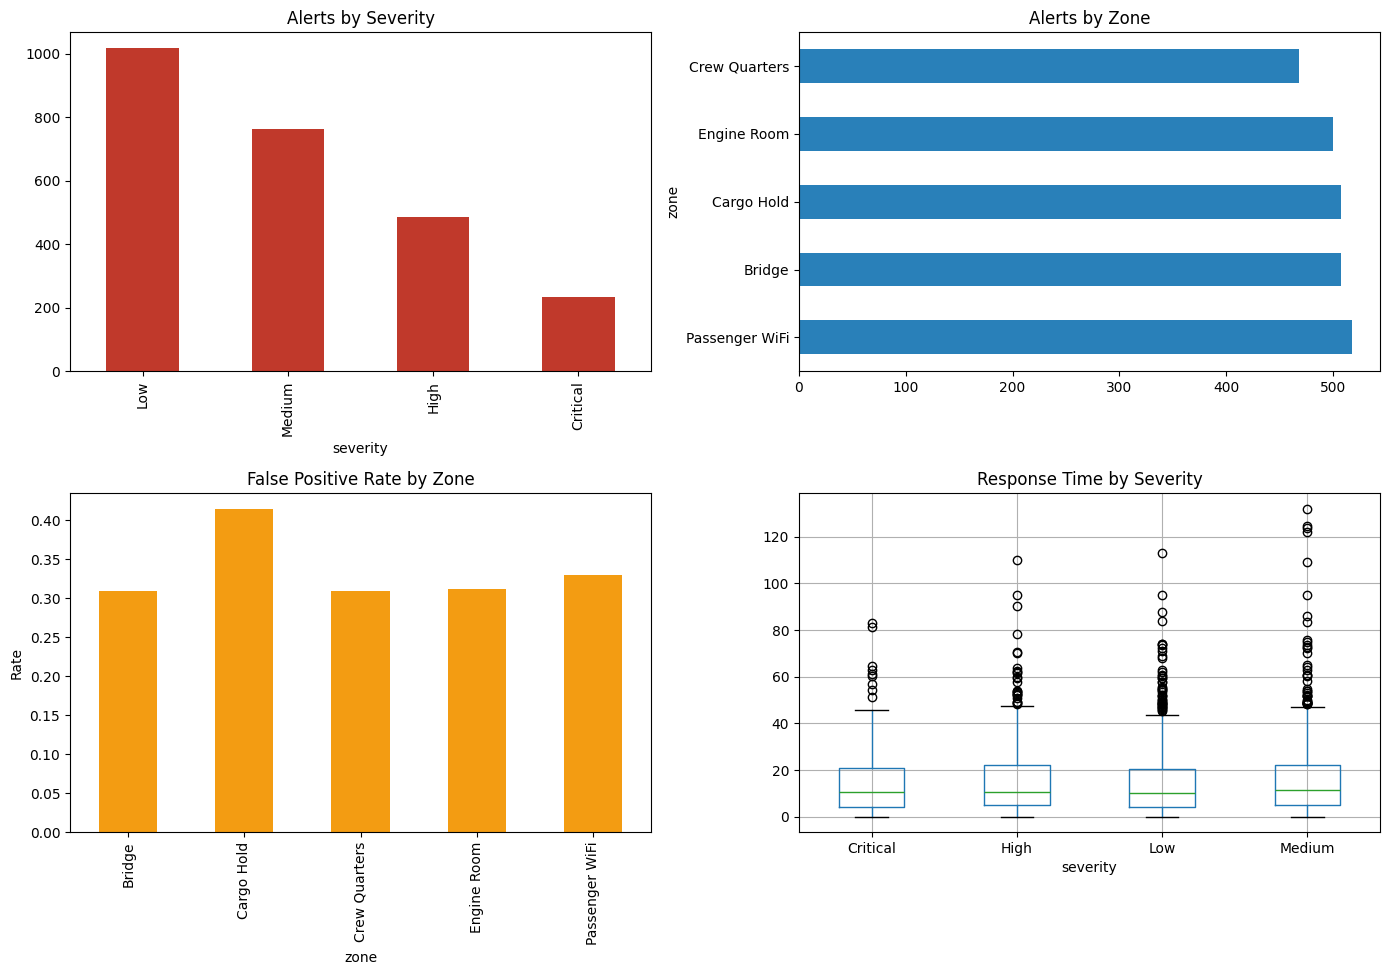

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
df['severity'].value_counts().reindex(severities).plot(kind='bar', ax=axes[0,0], color='#c0392b')
axes[0,0].set_title('Alerts by Severity')

df['zone'].value_counts().plot(kind='barh', ax=axes[0,1], color='#2980b9')
axes[0,1].set_title('Alerts by Zone')

df.groupby('zone')['false_positive'].mean().plot(kind='bar', ax=axes[1,0], color='#f39c12')
axes[1,0].set_title('False Positive Rate by Zone')
axes[1,0].set_ylabel('Rate')

df.boxplot(column='response_time_min', by='severity', ax=axes[1,1])
axes[1,1].set_title('Response Time by Severity')
plt.suptitle('')
plt.tight_layout()
plt.savefig('fathomids_analysis_charts.png', dpi=120)
plt.show()

## Step 3: Key Insights
Summarizing the patterns from the charts above into concrete findings and a recommendation.

In [ ]:
top_zone = df['zone'].value_counts().idxmax()
fp_rate = df['false_positive'].mean() * 100
avg_response = df['response_time_min'].mean()

insights = f"""# FathomIDS Alert Analytics — Key Insights

## Dataset Summary
- Total alerts analyzed: {len(df)}
- Date range: {df['timestamp'].min().date()} to {df['timestamp'].max().date()}

## Key Findings
- **{top_zone}** generated the highest volume of alerts, suggesting it needs the most monitoring attention.
- Overall false-positive rate: **{fp_rate:.1f}%**, indicating room for alert-tuning improvements.
- Average response time across all alerts: **{avg_response:.1f} minutes**.
- Critical severity alerts should be prioritized for fastest response given limited IT staff availability offline.

Passenger WiFi likely tops the alert count because it's the most open and least controlled segment of the ship's network — unlike the Bridge or Engine Room, which only authorized crew access, Passenger WiFi is used by hundreds of guests connecting personal devices with unknown security postures. This makes it a natural entry point for scans and failed login attempts, and explains why it also shows one of the higher false-positive rates: more traffic and device diversity means more noisy, borderline alerts for the system to sort through.

## Recommendation
Prioritize {top_zone} for additional segmentation/monitoring, and investigate false-positive
tuning to reduce noise and improve responder trust in the alert system.
"""
with open('README_insights.md', 'w') as f:
    f.write(insights)
print(insights)

# FathomIDS Alert Analytics — Key Insights

## Dataset Summary
- Total alerts analyzed: 2500
- Date range: 2026-01-01 to 2026-05-19

## Key Findings
- **Passenger WiFi** generated the highest volume of alerts, suggesting it needs the most monitoring attention.
- Overall false-positive rate: **33.6%**, indicating room for alert-tuning improvements.
- Average response time across all alerts: **15.3 minutes**.
- Critical severity alerts should be prioritized for fastest response given limited IT staff availability offline.

Passenger WiFi likely tops the alert count because it's the most open and least controlled segment of the ship's network — unlike the Bridge or Engine Room, which only authorized crew access, Passenger WiFi is used by hundreds of guests connecting personal devices with unknown security postures. This makes it a natural entry point for scans and failed login attempts, and explains why it also shows one of the higher false-positive rates: more traffic and device diversit

## Step 4: Project Documentation
Writing a README so anyone viewing this repo understands the project scope and file structure at a glance.

In [ ]:
full_readme = """# FathomIDS Alert Analytics

## Overview
Data analysis project examining security alert patterns from FathomIDS,
a network security monitoring system for maritime IT infrastructure.

## Skills Demonstrated
- Data cleaning and preprocessing (Python, pandas)
- Exploratory data analysis
- Data visualization (matplotlib)
- Statistical summarization and pattern detection
- Insight generation and business recommendations

## Files
- fathomids_alerts.csv — Raw alert dataset (2,500 records)
- fathomids_analysis_charts.png — Visualization dashboard
- README_insights.md — Key findings and recommendations

## How to Run
Open the notebook in Google Colab or Jupyter and run all cells top to bottom.
No external data download needed — the dataset is generated within the notebook.
"""
with open('README.md', 'w') as f:
    f.write(full_readme)
print(full_readme)

# FathomIDS Alert Analytics

## Overview
Data analysis project examining security alert patterns from FathomIDS,
a network security monitoring system for maritime IT infrastructure.

## Skills Demonstrated
- Data cleaning and preprocessing (Python, pandas)
- Exploratory data analysis
- Data visualization (matplotlib)
- Statistical summarization and pattern detection
- Insight generation and business recommendations

## Files
- fathomids_alerts.csv — Raw alert dataset (2,500 records)
- fathomids_analysis_charts.png — Visualization dashboard
- README_insights.md — Key findings and recommendations

## How to Run
Open the notebook in Google Colab or Jupyter and run all cells top to bottom.
No external data download needed — the dataset is generated within the notebook.



## Step 5: Package for Distribution
Bundling all deliverables — data, visuals, and findings — into a single archive.

In [ ]:
files_to_zip = ['README.md', 'README_insights.md', 'fathomids_alerts.csv', 'fathomids_analysis_charts.png']
missing = [f for f in files_to_zip if not os.path.exists(f)]
if missing:
    print("MISSING:", missing)
else:
    if os.path.exists('FathomIDS_Alert_Analytics.zip'):
        os.remove('FathomIDS_Alert_Analytics.zip')
    with __import__('zipfile').ZipFile('FathomIDS_Alert_Analytics.zip', 'w') as zf:
        for fname in files_to_zip:
            zf.write(fname)
    size_kb = os.path.getsize('FathomIDS_Alert_Analytics.zip') / 1024
    print(f"Zip created: FathomIDS_Alert_Analytics.zip ({size_kb:.1f} KB)")
    for fname in files_to_zip:
        print(f"  Included: {fname}")

Zip created: FathomIDS_Alert_Analytics.zip (270.0 KB)
  Included: README.md
  Included: README_insights.md
  Included: fathomids_alerts.csv
  Included: fathomids_analysis_charts.png


## Conclusion
This analysis identified Passenger WiFi as the highest-risk network zone and quantified the alert system's ~34% false-positive rate, translating raw security logs into a concrete monitoring recommendation. Full findings are documented in README_insights.md.